# Example: solving the forward problem

In [37]:
from odil_wave import Grid
grid = Grid(nx = 50, ny = 50, xmin=0.0, xmax=1.0, ymin=0.0, ymax=1.0, c_ref=1.7)

In [38]:
print(grid.summary)

Nx, Ny, Nt: 50, 50, 246
dx, dy, dt: 0.0204m, 0.0204m, 0.0068s
,CFL (at c = 1.7):  0.800
x in [0.00, 1.00]m
y in [0.00, 1.00]m


The time discretisation is computed automatically from the spatial spec according to the CFL condition.

From a `Grid`, we can start to build the other components of the problem. First, let's build a velocity model.

<Axes: title={'center': 'c(x, y) [Circular Anomaly Model]'}, xlabel='x [m]', ylabel='y [m]'>

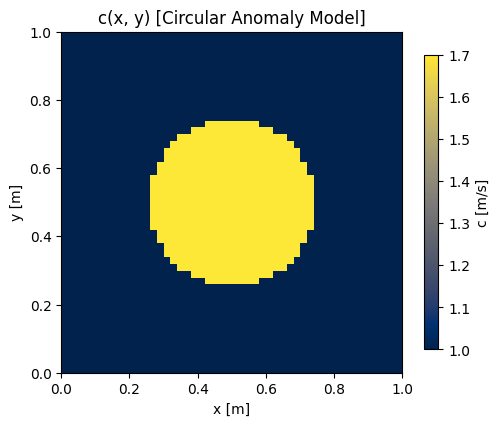

In [39]:
from odil_wave import OverDensityModel

model = OverDensityModel(grid, centre=(0.5, 0.5), radius=0.25)
model.show()

Amplitude data can be represented by a `Wavefield` object:

In [40]:
from odil_wave import Wavefield
wavefield = Wavefield(grid=grid)

Amplitude data is initialised to zero by default.

To drive wave propagation, we need a source term. We can define sources using the `Sources` class. Sources can be placed in a ring, or using custom spatial position in (x, y) coordinates. Source injection is controlled by sinc interpolation, which is a way to represent a point source exactly on a discrete grid. 

In [41]:
from odil_wave.geometry import Sources 
sources = Sources(grid, n_sources=1, f0=5, mode="custom", source_locs=((0.5, 0.9),))

<Axes: title={'center': 'Sources on Circular Anomaly Model'}, xlabel='x [m]', ylabel='y [m]'>

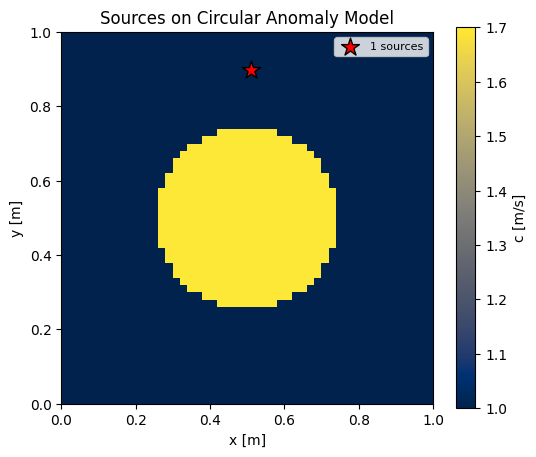

In [42]:
sources.show(model)

<Axes: title={'center': 'Ricker pulse ($f_0$=5 Hz, $t_0$=0.200 s)'}, xlabel='t [s]', ylabel='R(t) [a.u.]'>

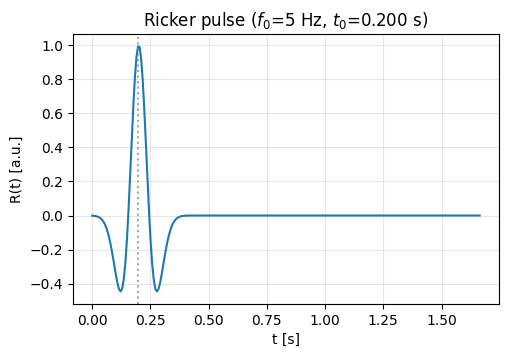

In [43]:
sources.plot_source_pulse()

We can now move towards the physics of our problem. The discretisation scheme is controlled by operators of type `Operator` and there are a few options, but thankfully we can just specify the desired method order in time and space to a `WaveEquation` object and it will construct our operators along with objects that apply initial and boundary conditions. 

In [44]:
from odil_wave import WaveEquation
wave_eq = WaveEquation(wavefield, model, time_order=2, space_order=2)

To form a loss function, we can use a `ForwardLoss` object that should be configured by defining our `Problem`.

In [45]:
from odil_wave import Problem
problem = Problem(wave_eq=wave_eq, geometry=sources)

In [46]:
from odil_wave import ForwardLoss
loss = ForwardLoss(problem=problem)

In [47]:
from odil_wave import LBFGSB
optimiser = LBFGSB(loss)

First, let's look at what the intial loss and gradient looks like:

In [48]:
import numpy as np

loss_val, grad = loss.evaluate(wavefield.U)
print("loss:", loss_val)
print("grad norm:", np.linalg.norm(grad))
print("grad max:", np.abs(grad).max())

loss: 0.1144633528314067
grad norm: 0.2920221486209357
grad max: 0.04367843694308419


Let's try to sove this small problem using a naive LBFGS.

In [49]:
from odil_wave.optimisation import LBFGSB
optimiser = LBFGSB(loss)

In [50]:
result, tape = optimiser.minimise(wavefield, maxiter=1000, ftol=1e-6, gtol=1e-8)

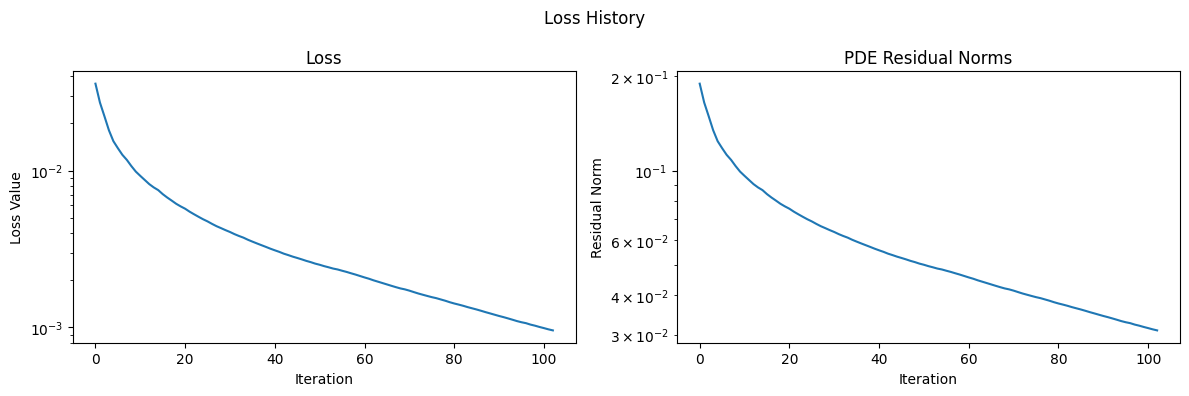

In [51]:
tape.show()

Finally, we can use the `wavefield`'s `.animate` utility to render a gif of the amplitude history over time.

In [52]:
outfile = result.animate()